# RADA Intensity Time Series by Chamber Location

This notebook creates a time series plot showing RADA fluorescence intensity across different chamber locations (Back, Middle, Opening).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

In [2]:
# Load data
df = pd.read_csv('1_fluo_binary_metabolic_gradient.csv')

In [4]:
# Bin chamber into spatial regions
bin_labels = {0: 'Back', 1: 'Middle', 2: 'Opening'}
df['y_bins'] = pd.cut(df['y'], bins=3, labels=False).astype(int)
df['y_bin_label'] = df['y_bins'].map(bin_labels)

# Convert frame number to hours (1 frame = 5 min)
df['time_hours'] = df['frame_number'] * (5 / 60)

# Compute mean and std per bin and time (across positions)
summary = df.groupby(['y_bin_label', 'time_hours'])['intensity_raw_mcherry'] \
            .agg(mean='mean', std='std').reset_index()

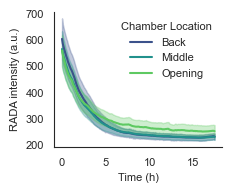

In [5]:
# Set publication style
sns.set_style("white")
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 8

# Create figure (6 cm × 5 cm)
fig, ax = plt.subplots(figsize=(6/2.54, 5/2.54))

# Color palette
bins_sorted = ['Back', 'Middle', 'Opening']
palette = sns.color_palette("viridis", n_colors=len(bins_sorted))

# Plot lines with shaded standard deviation
for i, bin_label in enumerate(bins_sorted):
    subset = summary[summary['y_bin_label'] == bin_label]
    x = subset['time_hours'].to_numpy()
    y = subset['mean'].to_numpy()
    y_std = subset['std'].to_numpy()
    
    ax.plot(x, y, color=palette[i], label=bin_label, linewidth=1.5)
    ax.fill_between(x, y - y_std, y + y_std, color=palette[i], alpha=0.3)

# Labels and styling
ax.set_xlabel('Time (h)')
ax.set_ylabel('RADA intensity (a.u.)')
ax.legend(title='Chamber Location', frameon=False, loc='upper right')
ax.tick_params(axis='both', which='both', direction='out', length=4, width=1)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()

# Export to PDF for Illustrator
plt.savefig('S7A_metabolic_gradient.pdf', format='pdf', dpi=300)
plt.show()

In [5]:
# Calculate bin sizes in micrometers
bin_sizes = df.groupby('y_bin_label')['y'].agg(['min', 'max'])
pixel_to_um = 0.065
bin_sizes['size_um'] = (bin_sizes['max'] - bin_sizes['min']) * pixel_to_um
print("Bin sizes:")
print(bin_sizes)

Bin sizes:
                    min         max    size_um
y_bin_label                                   
Back           2.920000  241.612903  15.515039
Middle       241.613636  480.306452  15.515033
Opening      480.306818  719.000000  15.515057
